# Time Series Forecasting - Exploratory Data Analysis

## Objective

The objective of this project is to forecast weekly sales for Walmart stores based on historical sales, store characteristics, and external economic indicators. I chose this dataset specifically because it includes built-in `IsHoliday` and store `Type`/`Size` features, allowing holiday and store-segment analysis without constructing a custom holiday calendar or segmentation logic. My initial candidate research directions for analysis are: 

1. Holiday effects — whether sales around holidays reflect genuine demand increase, or a shift in when purchases happen rather than a net gain.
    
2. Store-Type effects — whether store `Type` (A/B/C) and `Size` predict differences in sales level or volatility. 
    
3. Economic factors — whether external indicators (`CPI`, `Unemployment`, `Fuel_Price`) show a relationship with sales, and whether they interact with the holiday effect. 

Instead of committing to a single question first, I'm following a pattern-first approach: I'll use the EDA in this notebook to identify which of these candidate directions shows the clearest, most explainable signal, and then narrow down to a specific research question once the data justifies it. 

[placeholder — note which direction(s) held up, or dropped, and the finalized research question]

In this notebook, the objective is to understand the structure, distributions, and relationships in the merged Walmart sales dataset to inform which of these directions to pursue, how to prepare the data, and inform feature engineering decisions.

## Inputs
- `train.csv` — historical weekly sales by `Store`, `Dept`, `Date`, with `IsHoliday` flag
- `stores.csv` — store-level metadata: `Store`, `Type` (A/B/C), `Size`
- `features.csv` — store-week-level external factors: `Temperature`, `Fuel_Price`, `CPI`, `Unemployment`, `MarkDown1-5`, `IsHoliday`

Merged on `Store` (`train.csv` + `stores.csv`) and `['Store', 'Date']` (+ features), forming one dataframe of 421,570 rows spanning `2010-02-05` - `2012-10-26`.

## Outputs 
- Finalized research question
- Cleaning/feature engineering decisions
- Merged dataframe: `../data/processed/walmart_meged.csv`

## 1.1 Setup & Import

importing libraries and setting paths for reproducability

In [ ]:
import os # to ensure processed data path exists to save merged csv

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats # for t-test

sns.set_theme()
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)

FEATURES_PATH = '../data/raw/features.csv'
STORES_PATH = '../data/raw/stores.csv'
TRAIN_PATH = '../data/raw/train.csv'
RANDOM_STATE = 42

os.makedirs('../data/processed/', exist_ok=True)

Setting up the datafram combining the three datasets into one. This is done using pandas merge, merging train.csv with stores.csv on `Store`, and the dataframe from that merge with features.csv on `['Store', 'Date']`. Merging on `['Store', 'Date']` prevents the risk of duplicating rows from a partial or single-column join on a table that isn't one-row-per-key. 

In [14]:
train = pd.read_csv(TRAIN_PATH)
stores = pd.read_csv(STORES_PATH)
features = pd.read_csv(FEATURES_PATH)

In [15]:
df = train.merge(stores, on='Store', how='left')
df = df.merge(features, on=['Store', 'Date'], how='left')

In [16]:
# quick sanity check, df and train should have the same row count since i merged 'left'
print(df.shape) 
train.shape

(421570, 17)


(421570, 5)

The new dataframe and the train dataset having the same number of rows confirms the merge did not drop or duplicate rows.

## 1.2 Data Cleaning and Sanity Check

Because both `features.csv` and `train.csv` have a `IsHoliday` column, after merging, the new dataframe has `IsHoliday_x` and `IsHoliday_y`. If both of these columns are equivalent then I will drop one and rename the other to `IsHoliday` since it would be repetitive and uncecessary to keep both. 

In [17]:
(df['IsHoliday_x'] == df['IsHoliday_y']).value_counts()

True    421570
Name: count, dtype: int64

all rows of `IsHoliday_x` and `IsHoliday_y` are equivalent so I will drop `IsHoliday_y` and rename `IsHoliday_x` to `IsHoliday`. 

In [18]:
df = df.drop(columns=['IsHoliday_y'])
df = df.rename(columns={'IsHoliday_x': 'IsHoliday'})

### Datetime Conversion
To enable time-based plotting/resampling or sorting, I convert the dates to pandas datetime format. 

In [19]:
df['Date'] = pd.to_datetime(df['Date'])

### Missing Value Check
Looking at the raw data files and data description, I already know `features.csv` has mostly `NaN` for `MarkDown1-5`(they are only populated starting Nov 2011), so I will use `.isnull().sum()` to check the number of `NaN`s present in the dataframe. I will decide whether to drop them now, fill with 0s, or handle later if they are not central to patterns worth researching. 

In [7]:
df.isnull().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Type                 0
Size                 0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
dtype: int64

The only `NaN` values exist in the `MarkDown1-5` columns, which is expected. Since they do not affect any of the other variables of interest I will ignore them for now and defer handling to downstream feature engineering. This confirms no `NaN` missingness outside `MarkDowns1-5`, though non-obvious missing/impossible values still need checking.

The dataset description states that: MarkDown data is only available after Nov 2011, and is not available for all stores all the time. Any missing value is marked with an NA. Below I check whether the `NaN`s correctly disappear after Nov 2011. This confirms the `NaN`s are a documented data collection limitation that will be handled downstream in feature engineering. 

In [ ]:
df[df['MarkDown1'].notna()]['Date'].min(), 
df[df['MarkDown2'].notna()]['Date'].min(), 
df[df['MarkDown3'].notna()]['Date'].min(), 
df[df['MarkDown4'].notna()]['Date'].min(), 
df[df['MarkDown5'].notna()]['Date'].min()

(Timestamp('2011-11-11 00:00:00'),
 Timestamp('2011-11-11 00:00:00'),
 Timestamp('2011-11-11 00:00:00'),
 Timestamp('2011-11-11 00:00:00'),
 Timestamp('2011-11-11 00:00:00'))

The `min()` for `MarkDown1-5` being `2011-11-11 00:00:00` confirms `NaN`s disappear after Nov 2011. 

### Sanity Checks
I will check to make sure the data types of the features are as they should be, and use `.describe()` to check for any potential outliers or impossible values. 

In [9]:
df.dtypes

Store                    int64
Dept                     int64
Date            datetime64[us]
Weekly_Sales           float64
IsHoliday                 bool
Type                       str
Size                     int64
Temperature            float64
Fuel_Price             float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
CPI                    float64
Unemployment           float64
dtype: object

All `dtypes` of the features are correct.

In [10]:
df.describe()

,Store,Dept,Date,Weekly_Sales,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
count,421570.000000,421570.000000,421570,421570.000000,421570.000000,421570.000000,421570.000000,150681.000000,111248.000000,137091.000000,134967.000000,151432.000000,421570.000000,421570.000000
mean,22.200546,44.260317,2011-06-18 08:30:31.963375,15981.258123,136727.915739,60.090059,3.361027,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,171.201947,7.960289
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000,34875.000000,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000,93638.000000,46.680000,2.933000,2240.270000,41.600000,5.080000,504.220000,1878.440000,132.022667,6.891000
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000,140167.000000,62.090000,3.452000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,182.318780,7.866000
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500,202505.000000,74.280000,3.738000,9210.900000,1926.940000,103.990000,3595.040000,5563.800000,212.416993,8.572000
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000,219622.000000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000
std,12.785297,30.492054,NaN,22711.183519,60980.583328,18.447931,0.458515,8291.221345,9475.357325,9623.078290,6292.384031,5962.887455,39.159276,1.863296


- `Store`: Nothing stands out, slightly large difference between `max` (45) and `75%` (33), but no impossible values present. 

- `Dept`: This feature holds categorical/ID code values, so interpretation is different, but there appears to be no impossible value since the lowest `Dept` is 1.0. 

- `Date`: Similar to `Dept`, interpretation is different for this features, so nothing important to identify here. It may be helpful to know that the time frame ranges from `2010-02-05`-`2012-10-26`. 

- `Weekly_Sales`: Very big outlier, `max` is 693099.36 compared to `75%` 20205.85. Additionally, `50%` is only 7612.03, but `mean` is 15981.26. I expect to see a left skewed distribution for this feature. Also, The negative `min`(-4988.94), while not impossible, will either need to be dropped or kept as legitimate. I will defer the decision to keep or drop the negative sales to feature engineering. 

- `Size`: Nothing really stands out. The `max` (219622.00) and `75%` (202505.00) aren't too different, the `mean` (136727.92) and `50%` (140167.00) are relatively close.  The large `std` (60980.58) is not concerning given this feature captures stores sizes and sizes will nautrally vary.

- `Temperature`: Potential outlier of `max` 100.14 and `75%` 74.28, but `mean` and `50%` only differs by 2.0. A `min` of -2.00 isn't impossible. 

- `Fuel_Price`: Nothing to note, no impossible values or outliers. Very small `std` of 0.46. 

- `MarkDown1`: The `mean` (7246.42) and `50%` (5347.45)have a difference of ~2000, `min` of 0.27 is possible, the `75%` (9210.90) and `max` (88646.76) are very different, so an outlier exists. I expect to see a skewed distribution. 

- `MarkDown2`: Very negative `min` (-265.76), which is very suspicious since a negative mark down does not make real world sense. The `mean` (3334.62) and `50%` (192.0) are very different so there is likely an outlier, and the `75%` (1926.94) and `max` (104519.54) confirm this by the large difference.

- `MarkDown3`: `min` is -29, which again is suspicious since a negative mark down doesn't make sense. `mean` (1439.42) is very different from `50%` (24.60), and `75%`(103.99) and `max` (141630.61) are also very different. I expect to see a skewed distribution.

- `MarkDown4`: There is a large difference between `mean` (3383.16) and `50%` (1481.31), and an even larger difference between `max` (67474.85) and `75%`(3595.04). I expect to see a skewed distribution. The `min` is a possible 0.22. 

- `MarkDown5`:  `max` (108519.28) and `75%` (5563.80) have a very large difference, so `max` is an outlier. This is supported by the difference between `mean` (4628.97) and `50%` (3359.45). I expect to see a skewed distribution. 

All the `MarkDown` columns have differing counts, and are expected to show skewed distributions, which will need to be accounted for when comparing them.

- `CPI`: The `mean` (171.20) is slightly below `50%` (182.3), and `max` (227.23) and `75%` (212.41) differ slightly, so I expect to see a slightly left skewed distribution. `min` is 128.06, which is a realistic value.

- `unemployment`: `mean` (7.96) and `50%` (7.87) are relatively close, but there is a definite outlier in `max` (14.313000) since `75%` is 8.57. The `min` (3.87) is a realistic value. I expect to see a relatively balanced distribution with a long tail to the outlier. 

To check the distribution of `Type`, I use `value_counts()`, which is row-level and could be skewed by stores having different numbers of departments. To confirm the distribution reflects actual store counts rather than department density, I re-run it with `.drop_duplicates(subset='Store')` first.

In [7]:
print(df.drop_duplicates(subset='Store')['Type'].value_counts())
df['Type'].value_counts()

Type
A    22
B    17
C     6
Name: count, dtype: int64


Type
A    215478
B    163495
C     42597
Name: count, dtype: int64

Both outputs show `Type A` is most common, with `Type C` being notably rare — only 6 actual stores. This confirms the row-level imbalance is driven by store count, not department count. I'll need to account for this sample size limitation during analysis, since any apparent `Type C` effect could be noise from a small sample rather than a genuine pattern.

## 1.3 Univariate Analysis

To visualize and analyze the features, looking at distributions and potential outliers, I conduct univariate analysis using a histogram with a KDE curve overlay for the continuous variables (`Weekly_Sales`, `Size`, `Temperature`, `Fuel_Price`, `MarkDown1-5`, `CPI`, `Unemployment`), and countplots for the categorical/ID variables (`Type`, `IsHoliday`, `Store`, `Dept`). The KDE curve overlay plots a smoothed curve that makes it visually easier to see skew direction and multimodality. `Store` and `Dept` are included in categorical analysis because they are labels and their numeric values don't carry meaning in their magnitude or spacing. However, since they have high cardinality, I will use `set_xticks([])` to have a clean axis with just the bars. 

`Date` is excluded from this analysis since it will be examined separately later in the time series structure section, since its analytical value is in trend over time rather than distribution shape. 

### Continuous Features: 
`Weekly_Sales`, `Size`, `Temperature`, `Fuel_Price`, `MarkDown1-5`, `CPI`, `Unemployment`

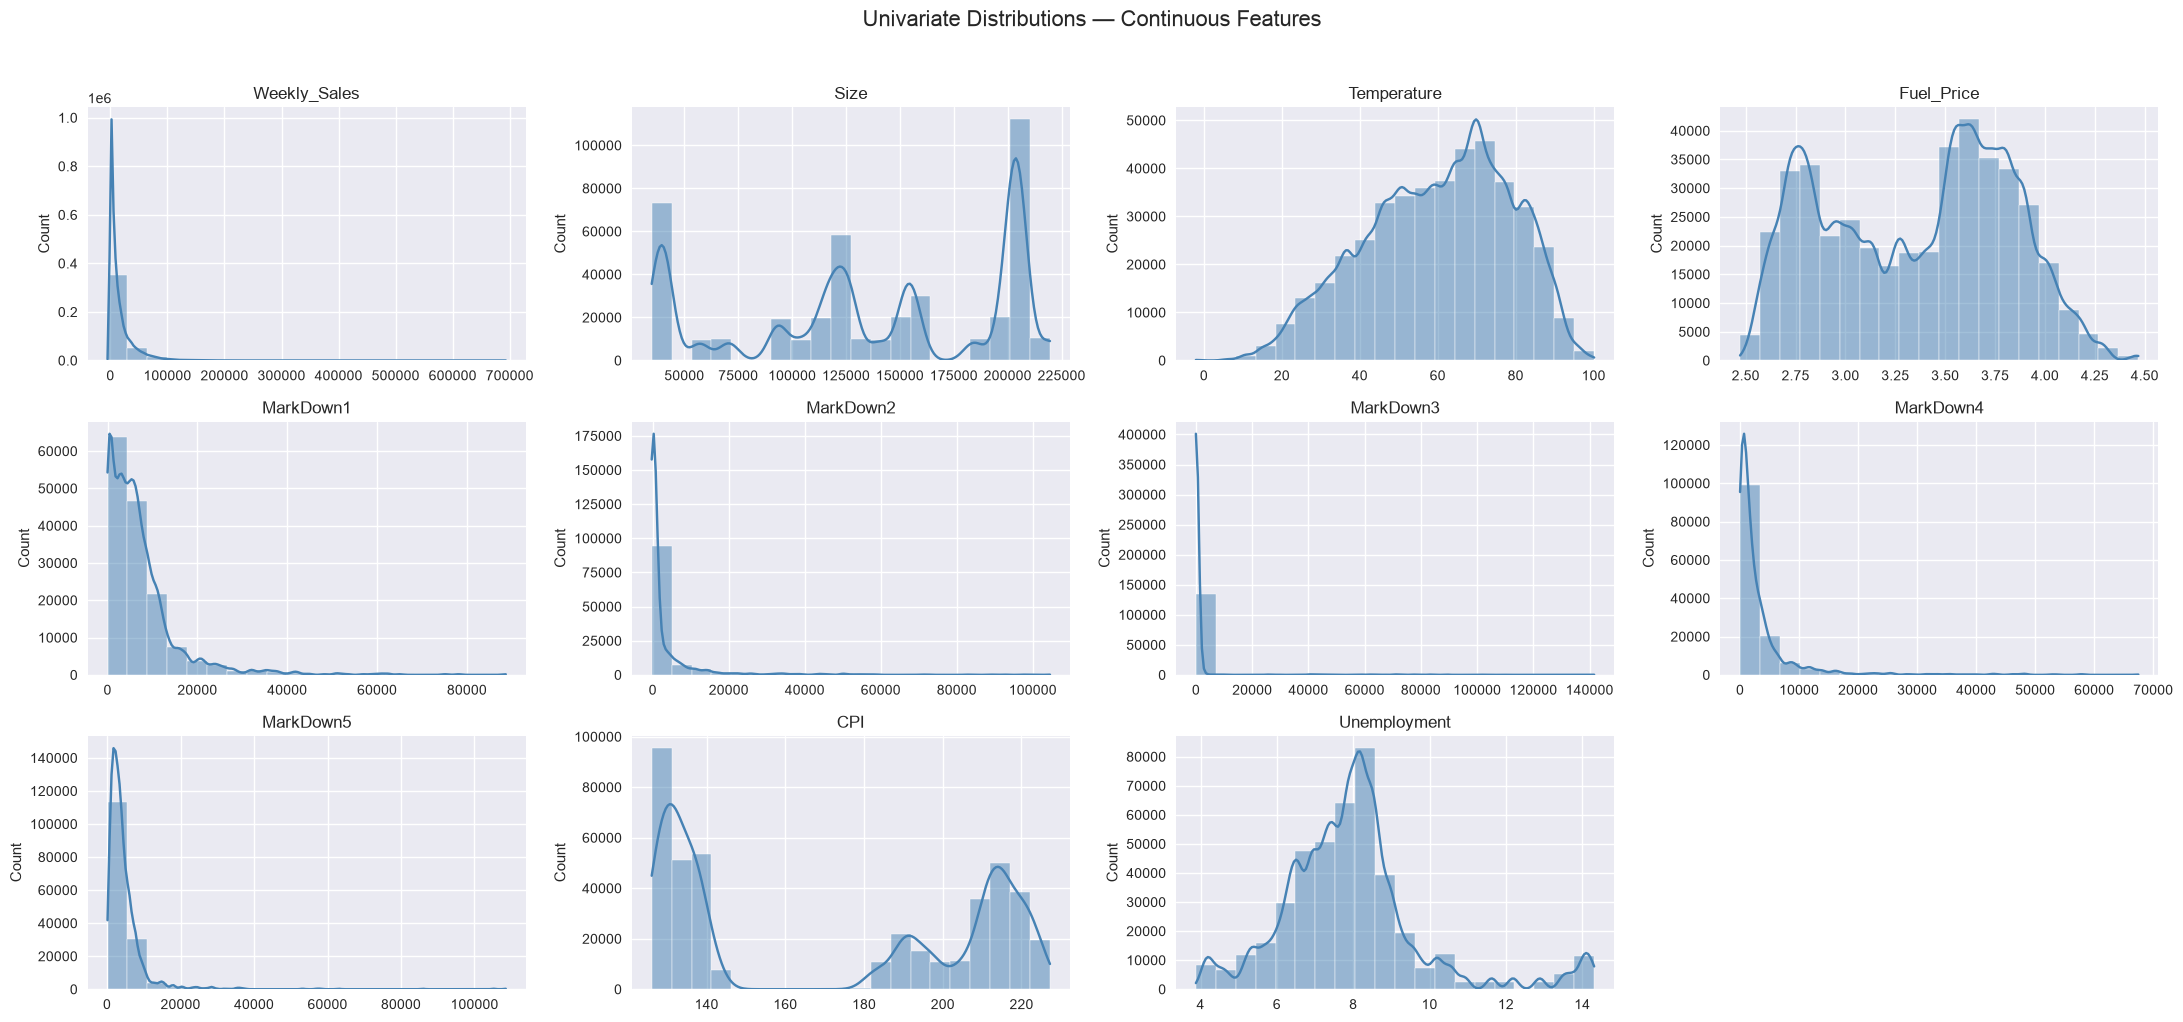

In [ ]:
continuous_features = ['Weekly_Sales', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment']

fig, axes = plt.subplots(3, 4, figsize=(22, 10))
axes = axes.flatten()

for i, feature in enumerate(continuous_features):
    sns.histplot(df[feature], bins=20, kde=True, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(feature)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

axes[-1].set_visible(False)

fig.suptitle('Univariate Distributions — Continuous Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../images/continuous_distributions.png', bbox_inches='tight')
plt.show()

- `Weekly_Sales`: Heavily right-skewed distribution as expected from sanity check — heavily right-skewed distributions are common for weekly sales data. The majority of sales are clustered near 0. Since the full-range histogram would never show negative numbers I'm relying on `.describe()` to confirm the negative min exists.

- `Size`: Has a multimodal distribution with multiple peaks, the highest around 200,000, likely reflecting distinct store-size categories/formats rather than a continuous skewed variable. 

- `Temperature`: This graph is slightly left skewed. The highest peak is around 70. 

- `Fuel_Price`: This is bimodal with a peak at ~2.75 and another ~3.60. 

- `MarkDown1-5`: As expected all the `MarkDown`s are heavily right skewed. Since all the `Markdown`s have different counts the graphs themselves can be misleading, but overall they share roughly the same shape and distribution even if the counts and values are different. 

- `CPI`: Has the highest peak at ~120 and is flat at 0 from ~140-~180, and has another peak at ~210. The distribution is bimodal which likely reflects CPI's rise over time across the dataset's time span combined with store/region differences. 

- `Unemployment`: the distribution is slightly right skewed with most values between 4-8 and then a drastic drop from 9-14. 

### Categorical Features: 
`Type`, `IsHoliday`, `Store`, `Dept`

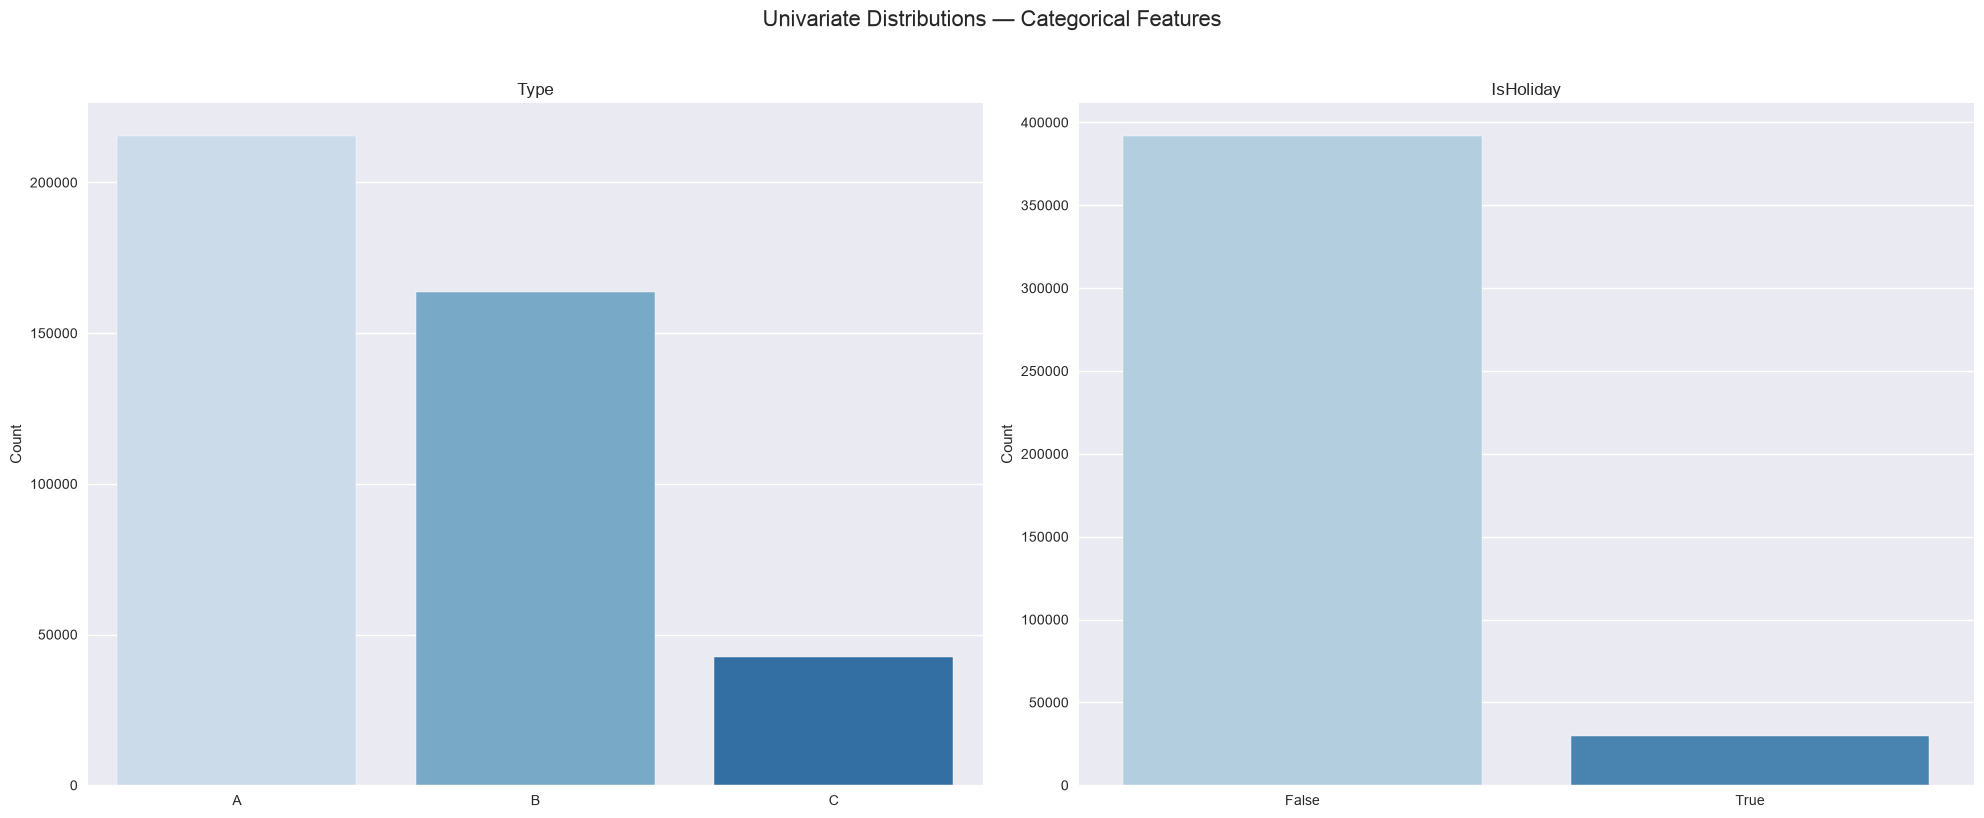

In [11]:
categorical_features = ['Type', 'IsHoliday']

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    sns.countplot(x=feature, data=df, ax=axes[i], palette='Blues', hue=feature, legend=False)
    axes[i].set_title(feature)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

fig.suptitle('Univariate Distributions — Categorical Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../images/categorical_distributions.png', bbox_inches='tight')
plt.show()

Both `Type` and `IsHoliday` are imbalanced, with `IsHoliday` being more heavily imbalanced. The imbalance in `Type` matches what was found earlier during sanity checks. `IsHoliday`'s imbalance makes sense since there are fewer holidays than normal operation days. These class imbalances will need to be dealt with down stream to ensure accurate downstream model evaluation.  

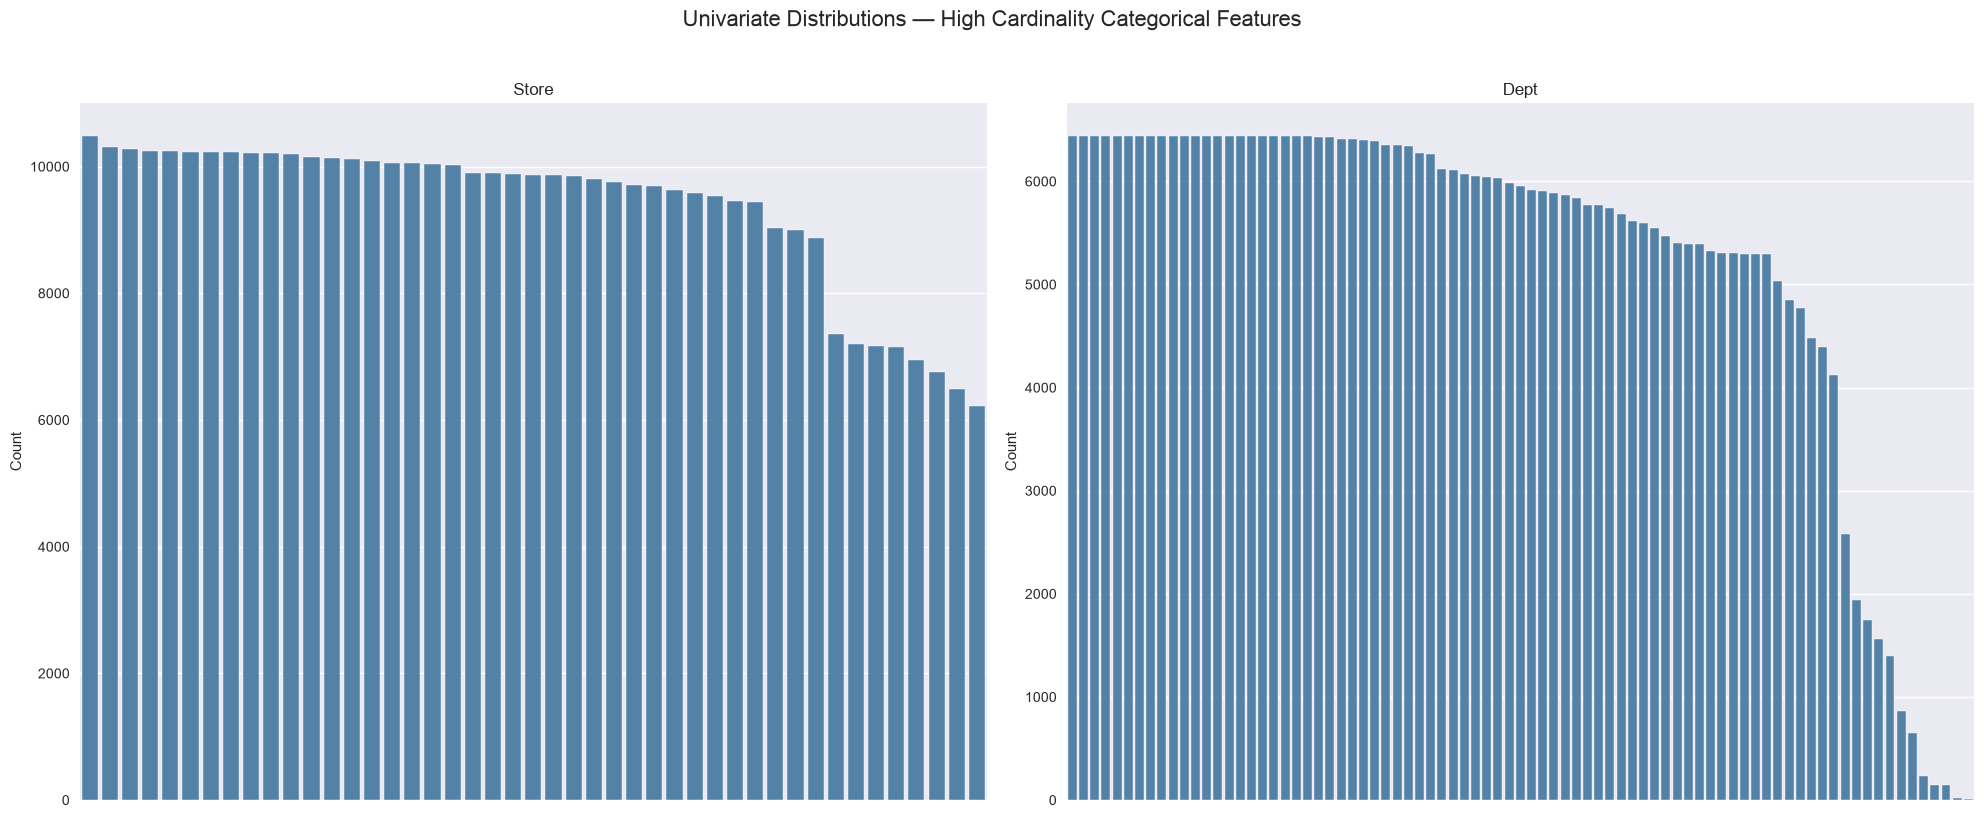

In [16]:
categorical_features = ['Store', 'Dept']

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    sns.countplot(x=feature, data=df, ax=axes[i], order=df[feature].value_counts().index, color='steelblue')
    axes[i].set_title(feature)
    axes[i].set_xticks([])
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

fig.suptitle('Univariate Distributions — High Cardinality Categorical Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../images/high_car_categorical_distributions.png', bbox_inches='tight')
plt.show()

Both `Store` and `Dept` have categories with noticeably fewer rows than others, with a gradual drop off — `Dept` having the steepest drop off. Since these are high-cardinality/ID features, the distribution doesn't say much about the data, but raises a potential question about a relationship between `Dept` and `Store`. 

## 1.4 Time Series Structure

To analyze time series structure, I will be checking for three things specifically: 
**Trend**: whether Walmart's overall sales level rising, flat, or declining over the ~3 years, **seasonality**: whether `Weekly_Sales` show a repeating annual pattern, and **context variables over time**: whether `CPI`, `Unemployment`, or `Fuel_Price` move meaningfully across the multi-year span. 

For trend analysis, I will use a rolling average of `Weekly_Sales` over `Date` with a window of 13 (~1 quarter) to smooth out week-to-week noise and reveal the underlying long-term direction. 



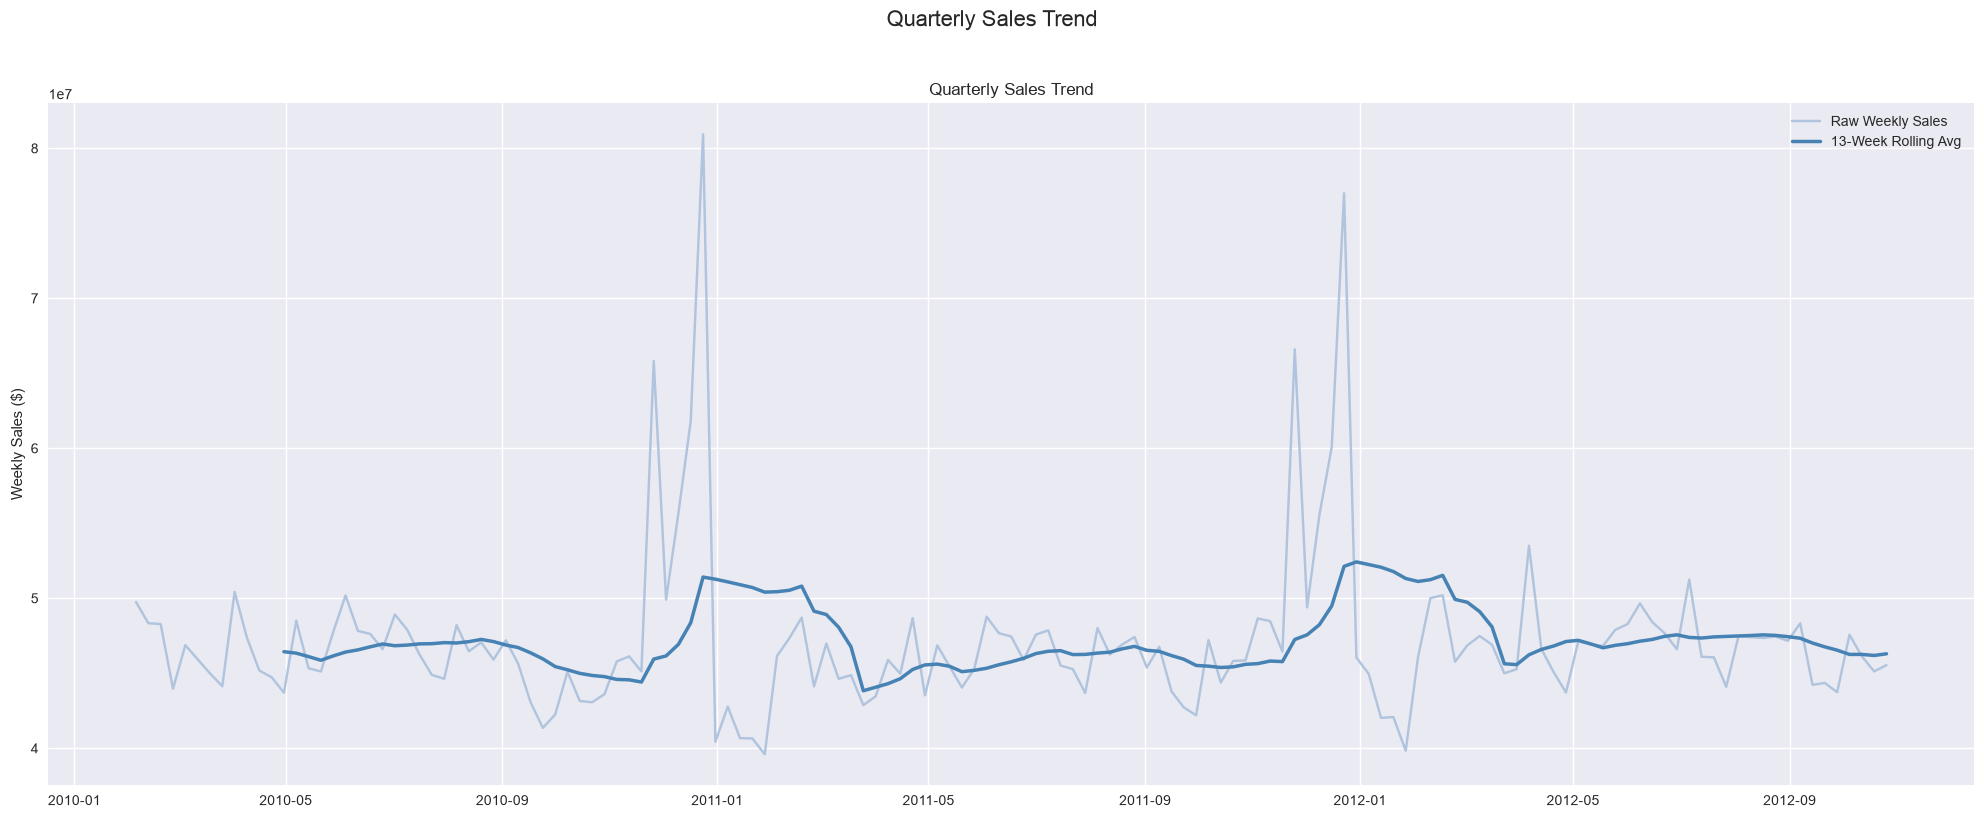

In [10]:
# Trend
daily_sales = df.groupby('Date')['Weekly_Sales'].sum().reset_index()
# rolling average
daily_sales['rolling_avg'] = daily_sales['Weekly_Sales'].rolling(window=13).mean()
# plot
fig, ax = plt.subplots(figsize=(20, 8))

sns.lineplot(data=daily_sales, x='Date', y='Weekly_Sales', color='lightsteelblue', label='Raw Weekly Sales', ax=ax)
sns.lineplot(data=daily_sales, x='Date', y='rolling_avg', color='steelblue', linewidth=2.5, label='13-Week Rolling Avg', ax=ax)

ax.set_title('Quarterly Sales Trend')
ax.set_xlabel('')
ax.set_ylabel('Weekly Sales ($)')

fig.suptitle('Quarterly Sales Trend', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../images/quarterly_sales_trend.png', bbox_inches='tight')
plt.show()

The `13-Week Rolling Avg` is roughly flat, ~4.8 `Weekly Sales`, with recurring bumps at roughly `2010-12` - `2011-03` and `2011-11` - `2012-03`. This shows that roughly at the end of every year, and going into the new year, weekly sales spikes. 

The `Raw Weekly Sales` line spikes just before the start of a new year (`2010-12` ~8, `2011-12` ~7.8), and drops dramatically at the start of the new year (`2011-01` ~4, `2012-01` ~4.6). On the other hand, the rolling average doesn't have a sharp peak, it has more of a plateau (~5.2) from the end of the previous year going into the first ~3 months of the new year. 

This gap shows that there is no **trend**, in this dataset, showing Walmart's overall sales rising over the ~3 year time frame, but it does show evidence of seasonality — likely connected to holidays (Thanksgiving and Christmas). 

However, `IsHoliday` also flags the Super Bowl (02) and Labor Day (09) as holidays, but from the raw sales plot, 02 shows a small spike in sales from the beginning of the new years ~4.0 to ~5.0 around 02, and no real spike at 09. The likely explanation for the lack of a significant spike is that holidays like Thanksgiving and Christmas are gift buying seasons, customers spend on lots of stuff across nearly every product category, but the Super Bowl has a short-lived effect, where a subset of shoppers likely buy food/snacks/TVs. Labor Day, is just a day off work and not a historically major shopping driven holiday. 

**Seasonality** will be more officially checked using a year-over-year overlay. 

The trend plot suggests a holiday-driven spike, so checking whether `IsHoliday` weeks actually cluster in Nov/Dec/Jan would confirm this. 

In [11]:
holiday_weeks = df.loc[df['IsHoliday']==True, 'Date']
holiday_weeks.dt.month.value_counts()

Date
2     8895
9     8861
11    5959
12    5946
Name: count, dtype: int64

Given that the `IsHoliday` flags four specific holidays and dates according to the data documentation, Super Bowl: 12-Feb-10, 11-Feb-11, 10-Feb-12, 8-Feb-13, Labor Day: 10-Sep-10, 9-Sep-11, 7-Sep-12, 6-Sep-13, Thanksgiving: 26-Nov-10, 25-Nov-11, 23-Nov-12, 29-Nov-13, and Christmas: 31-Dec-10, 30-Dec-11, 28-Dec-12, 27-Dec-13. The `.value_counts()` match the expected data (2 -> Super Bowl, 9 -> Labor Day, 11 -> Thanksgiving, and 12 -> Christmas). 

### Seasonality Year-Over-Year Overlay

I will use a year-over-year overlay plot to confirm if there is seasonality in Walmart's sales, because using an overlay allows me to clearly see if there is seasonality — if the years follow a similar shape and peak in the same general region, that's a sign of consistent seasonal behavior rather than random fluctuation.

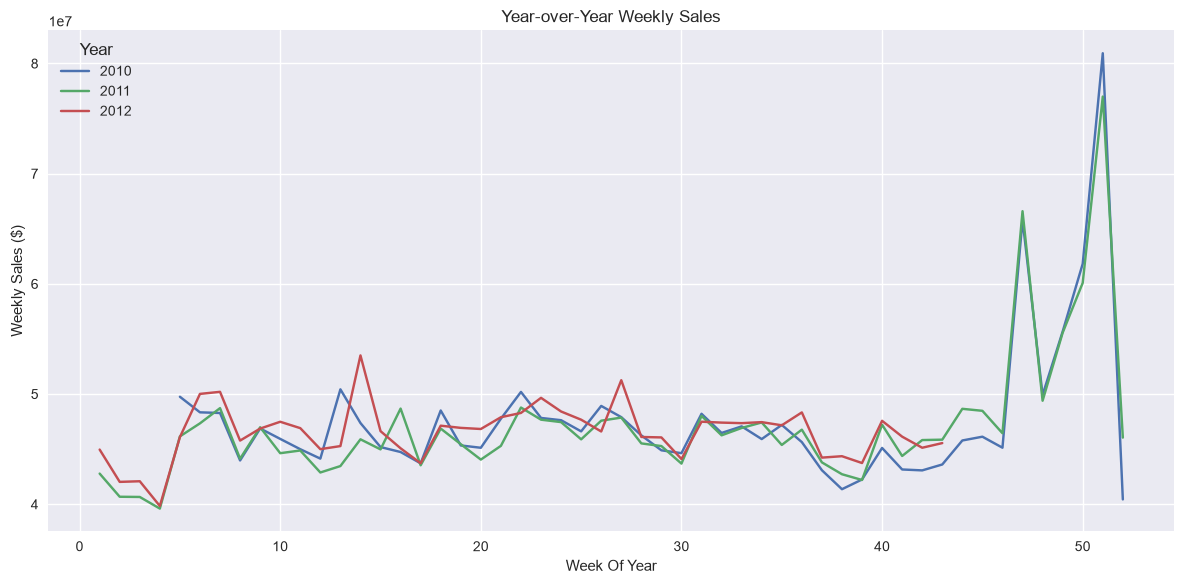

In [14]:
df['Year'] = df['Date'].dt.year
df['Week'] = df['Date'].dt.isocalendar().week

weekly_by_year = df.groupby(['Year', 'Week'])['Weekly_Sales'].sum().reset_index()

# pivot so each year becomes its own column, indexed by week
yoy_pivot = weekly_by_year.pivot(index='Week', columns='Year', values='Weekly_Sales')

# plot
ax = yoy_pivot.plot(figsize=(12,6))
ax.set_xlabel('Week Of Year')
ax.set_ylabel('Weekly Sales ($)')
ax.set_title('Year-over-Year Weekly Sales')

plt.tight_layout()
plt.savefig('../images/yoy_weekly_sales.png', bbox_inches='tight')
plt.show()

From week 0 - ~40, the years are relatively close but still distinct. Around week 47, 2010 and 2011 overlap alomst completely at the first spike, though 2010 peaks slightly higher at the second spike around week 51 (the highest point in the dataset). 2012 stops around week 43, since thats the extent of the data for that year. 

Despite these differences, the lines track a similar shape, with the sharpest spike consistently occuring in the same general region (high-40s to low-50s) each year. This confirms the seasonality suggested by the trend plot. 

### Context Variables Over Time

I examine `CPI`, `Unemployment`, and `Fuel_Price` ove the full data range to check whether any of these external economic variables show a pattern that might help explain sales trend and seasonality found above — specifically whether any of them move in a way that lines up with the Nov/Dec sales spike.

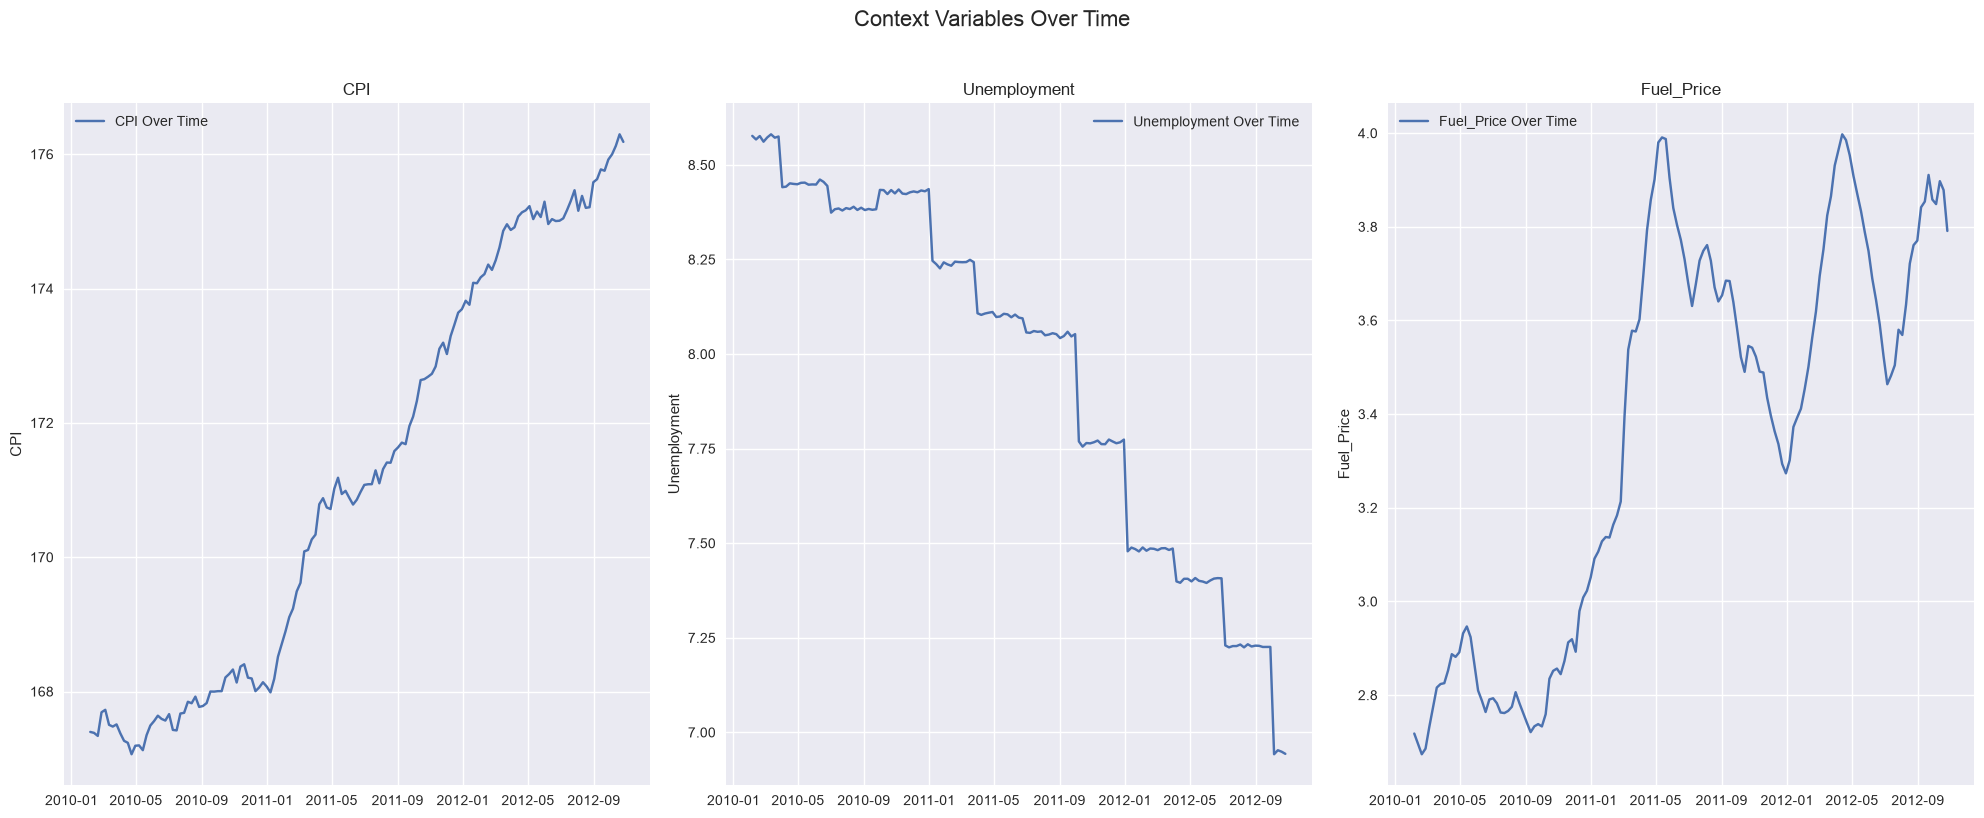

In [15]:
context_vars = df.groupby('Date')[['CPI', 'Unemployment', 'Fuel_Price']].mean().reset_index()

# plot
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
axes = axes.flatten()

for i, feature in enumerate(['CPI', 'Unemployment', 'Fuel_Price']):
    sns.lineplot(data=context_vars, x='Date', y=feature, label=f'{feature} Over Time', ax=axes[i])
    axes[i].set_title(feature)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(feature)

fig.suptitle('Context Variables Over Time', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../images/context_variables_over_time.png', bbox_inches='tight')
plt.show()

- `CPI`: have a relativelt steady increase from around `2010-01` to `2012-10`. This means `CPI` is going up over time which makes sense becuase of inflation. There is no real visually noticable correlation between `CPI` and the trend plot. 

- `Unemployment`: has a decreasing steps pattern across the whole range starting at ~8.60 to ~6.90, showing a downward trend in unemployment. This is overall a good trend for economic health for unemployment to be going down. There is no visually noticable correlation between `Unemployment` and the trend plot. 

- `Fuel_Price`: is far less consistent than the other two featurs. It shows a small peak around `2010-05` (~2.9), spikes near `2011-05` to ~4.0, falls to ~3.3 by `2012-01`, spikes again at `2012-05` to ~4.0, and falls to ~3.5 by `2012-07` before rising again again to ~3.9 on `2012-09` (where the data ends). Fuel prices appear to fluctate on a roughly annual cycle, generally peaking in spring, but the pattern isn't fully consistent — 2010 into 2011 shows fuel price rising into year-end, while 2011 into 2012 shows it falling into year-end. Given this inconsistency, I don't think fuel price reliably explains the Nov/Dec sales spike seen in the trend plot, since the two don't move together in a dependable direction. 

## 1.5 Segment Comparison

In the previous section I found that the dataset has seasonality, so in this section I want to see if the holiday spike found earlier shows up consistently across store types, or whether it's concentrated in some types and flat in others. 

To do this I will first isolate the rows that are during `Christmas` and `Thanksgiving` using `IsHoliday == True` combined with month — those were the holidays where sales actually spike — along with a `Normal` (non-holiday) baseline for comparison, since comparing holdiday averages to each other alone can't tell me whether a given type's sales are actually elevated or just generally large. Then
I group by `Type`/`Holiday` on `Weekly_Sales`. To average the sales I use `.mean()` since using raw sums would just reflect how many stores are in a certain type not how the type performs — sanity checks showed imbalance in `Type` (`A`: 22, `B`: 17, `C`: 6). `.mean()` normalizes this by dividing the sum by the counts of stores, ensuring the bargraph I plot is not visually misleading. 

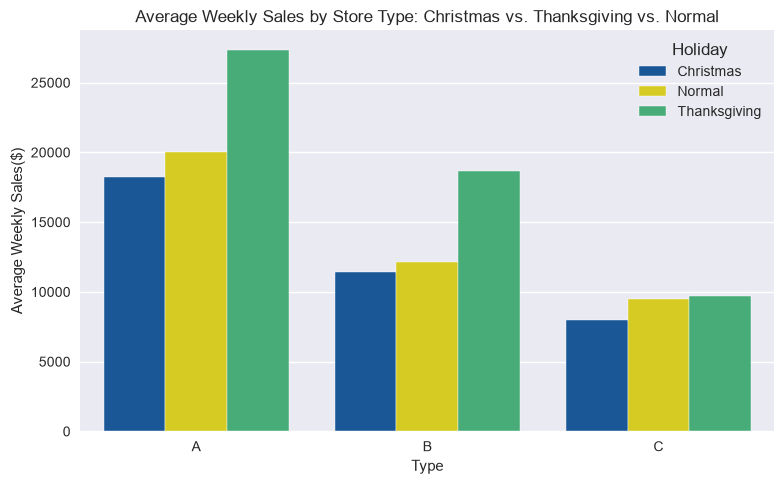

  Type       Holiday  Weekly_Sales
0    A     Christmas  18231.031306
1    A        Normal  20008.746759
2    A  Thanksgiving  27370.728296
3    B     Christmas  11394.051524
4    B        Normal  12153.067752
5    B  Thanksgiving  18661.296519
6    C     Christmas   7963.228980
7    C        Normal   9518.528116
8    C  Thanksgiving   9679.900152


In [15]:
# isolate just chirtmas and thanksgiving rows
christmas = df.loc[(df['IsHoliday']==True) & (df['Date'].dt.month == 12), ['Type', 'Weekly_Sales']]
thanksgiving = df.loc[(df['IsHoliday']==True) & (df['Date'].dt.month == 11), ['Type', 'Weekly_Sales']]
christmas['Holiday'] = 'Christmas'
thanksgiving['Holiday'] = 'Thanksgiving'

# isolate normal non-holiday rows for comparison
normal = df.loc[df['IsHoliday'] == False, ['Type', 'Weekly_Sales']]
normal['Holiday'] = 'Normal'

# concat for groupby
holidays = pd.concat([christmas[['Holiday', 'Type', 'Weekly_Sales']], thanksgiving[['Holiday', 'Type', 'Weekly_Sales']], normal[['Holiday', 'Type', 'Weekly_Sales']]], ignore_index=True)


segments = holidays.groupby(['Type', 'Holiday'])['Weekly_Sales'].mean().reset_index() # rest_index allows sns.barplot to refrence index by name

# plot
custom_palette = ['#0457ac', '#f4e604', '#37bd79']  # visual aesthetics

plt.figure(figsize=(8,5))
sns.barplot(x='Type', y='Weekly_Sales', hue='Holiday', data=segments, palette=custom_palette)
plt.title('Average Weekly Sales by Store Type: Christmas vs. Thanksgiving vs. Normal')
plt.ylabel('Average Weekly Sales($)')

plt.tight_layout()
plt.savefig('../images/avg_sales_by_type_CM_vs_TG_vs._N.png', bbox_inches='tight')
plt.show()
print(segments)


`Type A` has the highest average weekly sales overall, followed by `B`, and lastly `C` — consistent with the store count imbalance (`A`: 22, `B`: 17, `C`: 6) reflecting larger or more numerous `A` type stores.

Comparing each type's holiday sales to its own normal-week baseline shows a more precise picture than raw averages alone. `Christmas` is slightly below the normal-week baseline for all three types (`A`: ~18231.03 vs. ~20008.75, `B`: ~11394.05 vs. ~12153.07, `C`: ~7963.23 vs. ~9518.53) — meaning Christmas week itself does not show elevated sales in this store-type breakdown. `Thanksgiving`, on the other hand, shows a clear increase over `Normal` for `A` and `B` (`A`: ~1.37x `Normal`, `B`: ~1.54x `Normal`), while `C` is essentially flat (~1.02x `Normal`).

This means the holiday spike identified in the previous section is driven specifically by `Thanksgiving` week, not `Christmas`, and proportionally `Type B` sees the largest increase in sales relative to its own baseline, even though `A` has the highest absolute sales. `Type C` shows almost no holiday effect at all.

This makes sense given `Thanksgiving` week includes Black Friday, driving an immediate, broad in-store buying surge, whereas the actual `Christmas` week (the week containing Dec 25 itself) captures late or already-completed purchases rather than a fresh spike in shopping activity.

## 1.6 Holiday Effect Analysis

In this section I will quantify the magnitude of the holiday effect overall, looking at overall effect size comparing `IsHoliday == True` vs. `IsHoliday == False` weeks across the entire dataset. Unlike in the previous section, which broke the sales spike down by store type and found it concentrated in `Thanksgiving` specifically, this section looks at the entire dataset, regardless of store type, allowing for a fuller picture of overall holiday effect, including the `Super Bowl` and `Labor Day`, on sales. 

I run a Welch's t-test (`equal_var=False`) rather than a standard t-test because the holiday/non-holiday have different variance, since the spread of sales values within the holiday and normal groups aren't consistent — caused by the mix of the sharp `Thanksgiving` spike with flat `Super Bowl`/`Labor Day` weeks into one holiday group. 

In [ ]:
holiday_sales = df[df['IsHoliday']==True]['Weekly_Sales']
non_holiday_sales = df[df['IsHoliday']==False]['Weekly_Sales']

p_lift = (holiday_sales.mean() - non_holiday_sales.mean()) / non_holiday_sales.mean() * 100
print(f"percent lift: {p_lift}")

stats.ttest_ind(holiday_sales, non_holiday_sales, equal_var=False)

percent lift: 7.133805219708678


TtestResult(statistic=np.float64(7.000740275222608), pvalue=np.float64(2.595125026573972e-12), df=np.float64(32751.623666529573))

The t-test produced a p-value of ~2.595e-12, far below the conventional 0.05 threshold, indicating the holiday effect is statistically significant, unlikely by random chance. 
The overall percentage lift was ~7.13%, notably smaller than the type/holiday-specific lifts found in the previous section (`Type B `: ~1.54x, `Type A`: ~1.37x during `Thanksgiving`). This is because the other two holidays, the `Super Bowl`/`Labor Day`, are also included across all store types.

This shows there is a statistically significant, but modest, overall holiday effect across the entire dataset.

## 1.7 Dept-level Research Question

So far, analysis has shown that the holiday effects are real but concentrated in, not only time (`Thanksgiving` specifically, not `Christmas`), but also in store type (`B` proportinally highest, `C` flat). Combining these findings with the possible `Dept`/`Store` relationship noted in categorical univariate analysis, raises a natural question: 

"Does the `Thanksgiving` effect concentrate in specific `Depts`, while others show little to no holiday lift — mirroring the store-type level concentration?".

To answer this question I conduct a dept-level analysis, by grouping the hoidays dataframe, created in segment comparison, by `Dept` then rank the filtered dataframe by lift ratio per `Dept`, showing only the top and bottom 10 `Dept`s to identify where the effect concentrates most and least — with t-test to determine if values are statistically significant or just noise from low sample sizes.

In [11]:
# filter by Dept instead of type
christmas = df.loc[(df['IsHoliday']==True) & (df['Date'].dt.month == 12), ['Dept', 'Weekly_Sales']]
thanksgiving = df.loc[(df['IsHoliday']==True) & (df['Date'].dt.month == 11), ['Dept', 'Weekly_Sales']]
christmas['Holiday'] = 'Christmas'
thanksgiving['Holiday'] = 'Thanksgiving'

# isolate normal non-holiday rows for comparison
normal = df.loc[df['IsHoliday'] == False, ['Dept', 'Weekly_Sales']]
normal['Holiday'] = 'Normal'

# concat for groupby
holidays_dept = pd.concat([christmas, thanksgiving, normal], ignore_index=True)

# pivot so each Dept is a row and Holiday is Column
dept_pivot = holidays_dept.groupby(['Dept', 'Holiday'])['Weekly_Sales'].mean().unstack()

# calculate lift ratio and thn sort
dept_pivot['lift'] = dept_pivot['Thanksgiving'] / dept_pivot['Normal']
dept_pivot_sorted = dept_pivot.sort_values('lift', ascending=False)

# show only top and bottom 10
top_n = dept_pivot_sorted.head(10)
bottom_n = dept_pivot_sorted.tail(10)
print(f"Top 10: {top_n}")
print(f"Bottom 10: {bottom_n}")

Top 10: Holiday     Christmas        Normal   Thanksgiving       lift
Dept                                                         
99         380.000588    311.443638    3863.974500  12.406657
47        -110.575000     -8.822098     -49.500000   5.610910
72       55639.438837  47217.852117  242627.592235   5.138472
6         5733.200595   4513.898625   20641.205116   4.572811
77         119.050000    191.839706     774.055556   4.034908
18       16657.110222   6908.599161   27510.219111   3.982026
5        28038.090000  20538.617153   74191.033933   3.612270
55       19309.270759  10224.378094   36653.313333   3.584894
7        26637.672222  23702.744635   73230.768556   3.089548
14       17611.677444  14496.807073   36905.853444   2.545792
Bottom 10: Holiday     Christmas        Normal  Thanksgiving      lift
Dept                                                       
38       55212.348333  61392.797218  49007.937000  0.798269
3         7429.492222  11764.630795   9379.795556  0.7972

The top 10 `Dept`s show lifts ranging from ~2.5 to ~12.4, with most in the 3-5 range — substantially higher than the ~7.1% dataset-wide lift found in `Section 1.6`, confirming the effect is far more concentrated than the aggregate number suggested. The bottom 10 include several `Dept`s with lift below 1.0 (e.g. `Dept 16` at ~0.29, `Dept 56` at ~0.34), meaning Thanksgiving week is actually a sales dip relative to normal for these `Dept`s, not just a smaller lift — a genuinely opposite pattern rather than a weaker version of the same one.

To determine whether these extreme lift ratios reflect real effects or noise from small samples, I run a Welch's t-test (unequal variance assumed, consistent with `Section 1.6`) per `Dept`, comparing Thanksgiving-week `Weekly_Sales` against that `Dept`'s `Normal` baseline, and record `n_thanksgiving` alongside each result to assess statistical significance.

In [ ]:
depts_to_test = list(top_n.index) + list(bottom_n.index)

results = []
for dept in depts_to_test:
    tg_sales = df.loc[(df['Dept']==dept) & (df['IsHoliday']==True) & (df['Date'].dt.month==11), 'Weekly_Sales']
    normal_sales = df.loc[(df['Dept']==dept) & (df['IsHoliday']==False), 'Weekly_Sales']
    
    t_stat, p_val = stats.ttest_ind(tg_sales, normal_sales, equal_var=False)
    results.append({
        'Dept': dept,
        'lift': dept_pivot.loc[dept, 'lift'],
        'n_thanksgiving': len(tg_sales),
        'p_value': p_val
    })

dept_significance = pd.DataFrame(results).sort_values('lift', ascending=False)
print(dept_significance)

    Dept       lift  n_thanksgiving       p_value
0     99  12.406657              20  1.139851e-04
1     47   5.610910               2  7.736739e-01
2     72   5.138472              85  1.352527e-19
3      6   4.572811              86  1.063442e-22
4     77   4.034908              36  2.138180e-11
5     18   3.982026              90  1.870736e-16
6      5   3.612270              89  3.167292e-17
7     55   3.584894              78  2.566426e-22
8      7   3.089548              90  6.240140e-14
9     14   2.545792              90  4.856585e-15
10    38   0.798269              90  1.889878e-08
11     3   0.797288              90  3.241610e-04
12    50   0.727699              22  3.342205e-02
13    49   0.714744              60  2.405168e-04
14    51   0.669892              15  2.023233e-01
15    56   0.344312              84  8.665107e-45
16    16   0.286850              90  1.791220e-77
17    78  -0.202919               2  5.775076e-01
18    39        NaN               0           NaN


/var/folders/sh/kzg3lt_575x9y8ph83_wwrdc0000gn/T/ipykernel_63810/1768990182.py:8: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, p_val = stats.ttest_ind(tg_sales, normal_sales, equal_var=False)
/var/folders/sh/kzg3lt_575x9y8ph83_wwrdc0000gn/T/ipykernel_63810/1768990182.py:8: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, p_val = stats.ttest_ind(tg_sales, normal_sales, equal_var=False)


Looking at the p-values, the majority of `Dept`s — including all of the largest-lift `Dept`s with adequate sample sizes (e.g. `Dept 6`, `18`, `5`, `55`, `7`, `14`, and others in the 78-90 `n_thanksgiving` range) — have p-values dramatically below the 0.05 threshold, confirming the `Thanksgiving` lift is statistically significant for those `Dept`s. The exceptions to this are `Dept 47`, `78`, and `51`, all of which fail to reach significance threshold (p = ~0.77, ~0.58, ~0.20 respectively), and all three also have small `n_thanksgiving` (2, 2, and 15), consistent with low sample size rather than a genuine absence of effect. `Dept 78`'s negative lift(~-0.20) specifically reflects negative `Weekly_Sales` values in its 2-row sample — a known data-quality question (deferred to feature engineering) rather than a real Thanksgiving effect. `Dept 39` and `43` have no Thanksgiving-week sales at all (`n_thanksgiving = 0`), suggesting these `Dept`s may not operate in November at select stores. 

In [12]:
# Min n_thanksgiving threshold of 20, since below 20, t-test power is unreliable
MIN_N = 20  

dept_significance['reliable'] = dept_significance['n_thanksgiving'] >= MIN_N

# view flagged as unreliable
print(dept_significance[~dept_significance['reliable']])

# filter to reliable only
confirmed = dept_significance[dept_significance['reliable'] & (dept_significance['p_value'] < 0.05)]


    Dept      lift  n_thanksgiving   p_value  reliable
1     47  5.610910               2  0.773674     False
14    51  0.669892              15  0.202323     False
17    78 -0.202919               2  0.577508     False
18    39       NaN               0       NaN     False
19    43       NaN               0       NaN     False


Filtering to `n_thanksgiving >= 20` flags exactly the five `Dept`s discussed above (`47`, `78`, `51`, `39`, `43`) as statistically unreliable due to small sample size, confirming these should be excluded from claims about concentration. The remaining `Dept`s in confirmed represent the `Dept`s where the Thanksgiving effect is both large and statistically significant.

This analysis shows that Thanksgiving effect concentrates strongly in specific `Dept`s, mirroring the store-type concentration found in `Section 1.6`. Among `Dept`s with sufficient sample size (`n_thanksgiving >= 20`), lift ranges from ~0.29(a sales dip) to ~12.4, compared to the ~7.1% dataset-wide aggregate lift — confirming that the dataset-wide number masks dramatic underlying variation. The five `Dept`s with unreliable results are excluded from this conclusion since they require further investigation into why these `Dept`s have so little Thanksgiving-week data — a candidate for feature engineering or future work.

## 1.8 Saving Cleaned/Merged Dataframe 

Exporting the cleaned, merged dataframe created throughout EDA so it can be easily loaded in `02_feature_engineering.ipynb`  without needing to re-run the raw merge logic.

In [20]:
df.to_csv('../data/processed/walmart_merged.csv', index=False)
print(df.shape)

(421570, 16)


EDA output saved to `data/processed/walmart_merged.csv` (421570 rows).

## 1.8 Findings / Summary

### Findings:
- Confirmed `NaN`s correctly disappear after Nov 2011, deferred handling to feature engineering.
- Categorical univariate analysis raised a potential question on the relationship between `Dept` and `Store`. 
- Spikes in weekly sales occur near end of year (Nov/Dec), due to `Thanksgiving`/`Christmas` holidays. 
- Found seasonality in the dataset, no trend or context feature over-time correlation with sales.
- Segmentation comparison revealed `Thanksgiving` as the driver of sales spikes, with `Christmas` being slightly below `Normal` across all store types. `B` had the highest proportional lift, `C` was flat, and `A` had overall highest sales volume. 
- Overall holiday effect across the entire dataset is statistically significant (p-value: ~2.595e-12) with a modest lift of ~7.13%. 
- Found `Thanksgiving` effect is concentrated in specific `Depts` while others show little to no holiday lift — mirroring the store-type level concentration. 

### Feature Engineering Decisions
- Deal with `NaN`s in `MarkDown1-5`
- Deal with negative values in `Weekly_Sales`/`MarkDown 2/3`
- Identify why certain `Dept`s have so little Thanksgiving-week data
- Candidates for dropping, context variables, pending check
- Build lag features to capture autocorrelation/momentum that calendar features can't
- Temporal train/test split 